## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

In [3]:
# Path to BIDMC PhysioNet dataset
data_dir = Path(
    r"G:\1-1- Articles\1- Hybrid_Quantum_STATE_PREPRATION_VIA_DATA_COMPRESSION\Datasets\bidmc-ppg-and-respiration-dataset-1.0.0\bidmc_csv"
)

signal_files = sorted(
    data_dir.glob("*_Signals.csv")
)

print(f"Found {len(signal_files)} files")

Found 53 files


In [4]:
for f in signal_files[:5]:
    print(f.name)

bidmc_01_Signals.csv
bidmc_02_Signals.csv
bidmc_03_Signals.csv
bidmc_04_Signals.csv
bidmc_05_Signals.csv


In [5]:
lengths = []

for file in signal_files:

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip()

    ppg = df["PLETH"].astype(float).values

    lengths.append(len(ppg))

print("Signals:", len(lengths))
print("Min length:", min(lengths))
print("Max length:", max(lengths))
print("Mean length:", np.mean(lengths))

Signals: 53
Min length: 60001
Max length: 60001
Mean length: 60001.0


In [6]:
def load_ppg_signal(file_path):
    """
    Load a PPG waveform, zero-pad it to the next
    power of two, and normalize it.
    """

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip()

    signal = df["PLETH"].astype(float).values

    # Zero-padding
    N_orig = len(signal)

    next_pow2 = 2 ** math.ceil(
        math.log2(N_orig)
    )

    pad_len = next_pow2 - N_orig

    signal = np.pad(
        signal,
        (0, pad_len),
        mode="constant"
    )

    # Normalization
    signal = (
        signal /
        np.linalg.norm(signal)
    )

    return signal

In [7]:
signal = load_ppg_signal(
    signal_files[0]
)

print(signal.shape)
print(np.linalg.norm(signal))

(65536,)
0.9999999999999993


In [8]:
sizes = []

for file in signal_files:

    signal = load_ppg_signal(file)

    sizes.append(len(signal))

print(np.unique(sizes))

[65536]


In [11]:
signal = load_ppg_signal(
    signal_files[0]
)

print(signal[:1024].shape)

(1024,)


In [22]:
sig = signal[:1024]/ np.linalg.norm(signal[:1024])

In [23]:
level = 7

X = haar_packet_transform(
    signal[:1024],
    level
)

print(X.shape)

(1024,)


In [24]:
k = 200

X_top = top_k_threshold(
    X,
    k
)

print(
    np.count_nonzero(X_top)
)

200


In [25]:
X_norm = (
    X_top /
    np.linalg.norm(X_top)
)

In [26]:
print(
    np.linalg.norm(X_norm)
)

1.0


In [27]:
signal_rec = inverse_haar_packet_transform(
    X_norm,
    level
)

In [28]:
td = trace_distance(
    sig,
    signal_rec
)

print(td)

0.014825135712679979


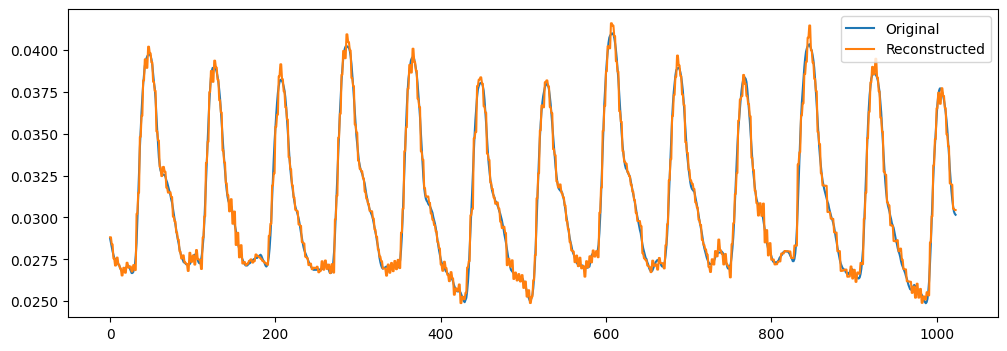

In [29]:
plt.figure(figsize=(12,4))

plt.plot(
    sig,
    label="Original"
)

plt.plot(
    signal_rec,
    label="Reconstructed"
)

plt.legend()
plt.show()

## k=3000

In [30]:
k = 200

levels = range(1, 10)

td_values = []

for level in levels:

    X = haar_packet_transform(
        signal[:1024],
        level
    )

    X_top = top_k_threshold(
        X,
        k
    )

    X_norm = (
        X_top /
        np.linalg.norm(X_top)
    )

    signal_rec = inverse_haar_packet_transform(
        X_norm,
        level
    )

    td = trace_distance(
        signal[:1024]/np.linalg.norm(signal[:1024]),
        signal_rec
    )

    td_values.append(td)

    print(
        f"L={level:2d} | TD={td:.6f}"
    )

L= 1 | TD=0.697344
L= 2 | TD=0.397814
L= 3 | TD=0.013702
L= 4 | TD=0.011230
L= 5 | TD=0.013130
L= 6 | TD=0.015497
L= 7 | TD=0.014825
L= 8 | TD=0.013185
L= 9 | TD=0.012354


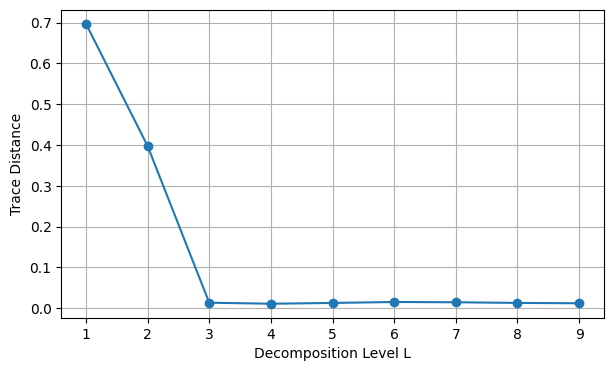

In [31]:
plt.figure(figsize=(7,4))

plt.plot(
    levels,
    td_values,
    "o-"
)

plt.xlabel("Decomposition Level L")
plt.ylabel("Trace Distance")
plt.grid(True)

plt.show()

In [32]:
best_idx = np.argmin(td_values)

best_level = list(levels)[best_idx]

best_td = td_values[best_idx]

print(
    f"Best level = {best_level}"
)

print(
    f"Best TD = {best_td:.6f}"
)

Best level = 4
Best TD = 0.011230


In [33]:
import pandas as pd

k = 110

levels = range(1, 10)

results = []

for signal_idx, file in enumerate(signal_files, start=1):

    signal = load_ppg_signal(file)

    td_values = []

    for level in levels:

        X = haar_packet_transform(
            signal[:1024],
            level
        )

        X_top = top_k_threshold(
            X,
            k
        )

        X_norm = (
            X_top /
            np.linalg.norm(X_top)
        )

        signal_rec = inverse_haar_packet_transform(
            X_norm,
            level
        )

        td = trace_distance(
            signal[:1024]/np.linalg.norm(signal[:1024]),
            signal_rec
        )

        td_values.append(td)

    best_idx = np.argmin(td_values)

    best_level = list(levels)[best_idx]

    best_td = td_values[best_idx]

    results.append(
        {
            "Signal": signal_idx,
            "Best Level": best_level,
            "Best TD": best_td,
        }
    )

    print(
        f"Signal {signal_idx:2d}"
        f" | Best L = {best_level}"
        f" | TD = {best_td:.6f}"
    )

Signal  1 | Best L = 9 | TD = 0.023745
Signal  2 | Best L = 8 | TD = 0.050714
Signal  3 | Best L = 8 | TD = 0.059216
Signal  4 | Best L = 9 | TD = 0.049449
Signal  5 | Best L = 9 | TD = 0.024128
Signal  6 | Best L = 4 | TD = 0.061271
Signal  7 | Best L = 9 | TD = 0.050080
Signal  8 | Best L = 9 | TD = 0.056644
Signal  9 | Best L = 4 | TD = 0.042003
Signal 10 | Best L = 9 | TD = 0.036518
Signal 11 | Best L = 8 | TD = 0.019676
Signal 12 | Best L = 9 | TD = 0.023886
Signal 13 | Best L = 4 | TD = 0.032701
Signal 14 | Best L = 9 | TD = 0.043026
Signal 15 | Best L = 9 | TD = 0.035517
Signal 16 | Best L = 9 | TD = 0.056209
Signal 17 | Best L = 4 | TD = 0.049576
Signal 18 | Best L = 8 | TD = 0.038655
Signal 19 | Best L = 9 | TD = 0.006463
Signal 20 | Best L = 9 | TD = 0.015700
Signal 21 | Best L = 9 | TD = 0.011430
Signal 22 | Best L = 4 | TD = 0.024405
Signal 23 | Best L = 5 | TD = 0.045522
Signal 24 | Best L = 8 | TD = 0.026093
Signal 25 | Best L = 9 | TD = 0.022659
Signal 26 | Best L = 4 | 

In [34]:
results_df = pd.DataFrame(results)

In [35]:
level_counts = (
    results_df["Best Level"]
    .value_counts()
    .sort_index()
)

print(level_counts)

Best Level
4    10
5     3
8     9
9    31
Name: count, dtype: int64


In [36]:
print(
    "Mean TD:",
    results_df["Best TD"].mean()
)

print(
    "Std TD:",
    results_df["Best TD"].std()
)

Mean TD: 0.036940974626787255
Std TD: 0.013846667968804927


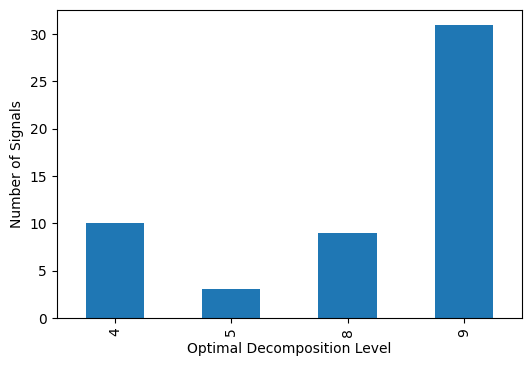

In [37]:
plt.figure(figsize=(6,4))

level_counts.plot(
    kind="bar"
)

plt.xlabel(
    "Optimal Decomposition Level"
)

plt.ylabel(
    "Number of Signals"
)

plt.show()

In [38]:
def analyze_dataset(k):

    levels = range(1, 10)

    results = []

    for signal_idx, file in enumerate(signal_files, start=1):

        signal = load_ppg_signal(file)

        td_values = []

        for level in levels:

            X = haar_packet_transform(
                signal[:1024],
                level
            )

            X_top = top_k_threshold(
                X,
                k
            )

            X_norm = (
                X_top /
                np.linalg.norm(X_top)
            )

            signal_rec = (
                inverse_haar_packet_transform(
                    X_norm,
                    level
                )
            )

            td = trace_distance(
                signal[:1024]/np.linalg.norm(signal[:1024]),
                signal_rec
            )

            td_values.append(td)

        best_idx = np.argmin(td_values)

        results.append(
            {
                "Signal": signal_idx,
                "Best Level": list(levels)[best_idx],
                "Best TD": td_values[best_idx],
            }
        )

    return pd.DataFrame(results)

In [39]:
results_10 = analyze_dataset(10)

results_100 = analyze_dataset(100)

results_200 = analyze_dataset(200)

In [40]:
for k, df in [
    (10, results_10),
    (100, results_100),
    (200, results_200),
]:

    print("\n")
    print(f"k = {k}")

    print(
        df["Best Level"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nMean TD:",
        df["Best TD"].mean()
    )

    print(
        "Std TD:",
        df["Best TD"].std()
    )



k = 10
Best Level
8     3
9    50
Name: count, dtype: int64

Mean TD: 0.17090731296675235
Std TD: 0.058400202606200526


k = 100
Best Level
4     6
5     3
8     9
9    35
Name: count, dtype: int64

Mean TD: 0.04070425185644896
Std TD: 0.015234066840043456


k = 200
Best Level
3     3
4    14
5     3
6     1
8     7
9    25
Name: count, dtype: int64

Mean TD: 0.018038167084008024
Std TD: 0.006903216754554677


In [42]:
results_10["Best Level"].mean(), results_100["Best Level"].mean(), results_200["Best Level"].mean()

(np.float64(8.943396226415095),
 np.float64(8.037735849056604),
 np.float64(6.9245283018867925))

In [43]:
def analyze_levels(k):

    levels = range(1, 10)

    all_td = []

    for file in signal_files:

        signal = load_ppg_signal(file)

        td_values = []

        for level in levels:

            X = haar_packet_transform(signal[:1024], level)

            X_top = top_k_threshold(X, k)

            X_norm = X_top / np.linalg.norm(X_top)

            signal_rec = inverse_haar_packet_transform(
                X_norm,
                level
            )

            td = trace_distance(
                signal[:1024]/np.linalg.norm(signal[:1024]),
                signal_rec
            )

            td_values.append(td)

        all_td.append(td_values)

    all_td = np.array(all_td)

    mean_td = all_td.mean(axis=0)
    std_td  = all_td.std(axis=0)

    return mean_td, std_td

In [44]:
mean_td_10, std_td_10 = analyze_levels(10)

mean_td_100, std_td_100 = analyze_levels(100)

mean_td_200, std_td_200 = analyze_levels(200)

<ErrorbarContainer object of 3 artists>

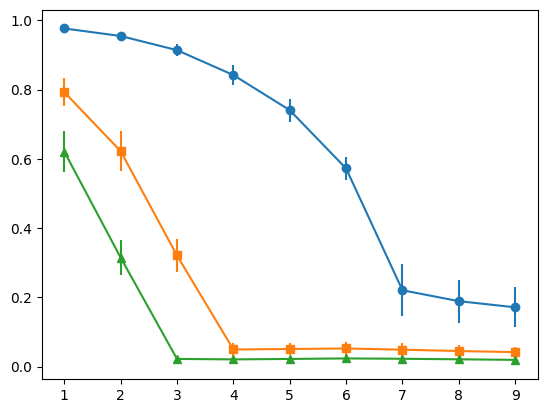

In [45]:
plt.errorbar(
    levels,
    mean_td_10,
    yerr=std_td_10,
    marker="o",
    label=r"$k=n^2$"    
)

plt.errorbar(
    levels,
    mean_td_100,
    yerr=std_td_100,
    marker="s",
    label=r"$k=6n^2$"
)

plt.errorbar(
    levels,
    mean_td_200,
    yerr=std_td_200,
    marker="^",
    label=r"$k=12n^2$"
)

# Plot the figure of the paper

In [47]:
levels = range(1, 10)

k_values = [10, 100, 200]

mean_td = {}
std_td = {}

for k in k_values:

    mean_td[k] = []
    std_td[k] = []

    print(f"\nProcessing k = {k}")

    for level in levels:

        td_list = []

        for file in signal_files:

            signal = load_ppg_signal(file)

            X = haar_packet_transform(
                signal[:1024],
                level
            )

            X_top = top_k_threshold(
                X,
                k
            )

            X_norm = (
                X_top /
                np.linalg.norm(X_top)
            )

            signal_rec = (
                inverse_haar_packet_transform(
                    X_norm,
                    level
                )
            )

            td = trace_distance(
                signal[:1024]/np.linalg.norm(signal[:1024]),
                signal_rec
            )

            td_list.append(td)

        mean_td[k].append(
            np.mean(td_list)
        )

        std_td[k].append(
            np.std(td_list)
        )

        print(
            f"L={level:2d} "
            f"Mean TD={np.mean(td_list):.5f}"
        )


Processing k = 10
L= 1 Mean TD=0.97668
L= 2 Mean TD=0.95482
L= 3 Mean TD=0.91401
L= 4 Mean TD=0.84209
L= 5 Mean TD=0.74067
L= 6 Mean TD=0.57224
L= 7 Mean TD=0.22044
L= 8 Mean TD=0.18900
L= 9 Mean TD=0.17118

Processing k = 100
L= 1 Mean TD=0.79276
L= 2 Mean TD=0.62223
L= 3 Mean TD=0.32089
L= 4 Mean TD=0.04948
L= 5 Mean TD=0.05075
L= 6 Mean TD=0.05236
L= 7 Mean TD=0.04886
L= 8 Mean TD=0.04492
L= 9 Mean TD=0.04171

Processing k = 200
L= 1 Mean TD=0.62112
L= 2 Mean TD=0.31491
L= 3 Mean TD=0.02213
L= 4 Mean TD=0.02080
L= 5 Mean TD=0.02208
L= 6 Mean TD=0.02358
L= 7 Mean TD=0.02259
L= 8 Mean TD=0.02103
L= 9 Mean TD=0.01945


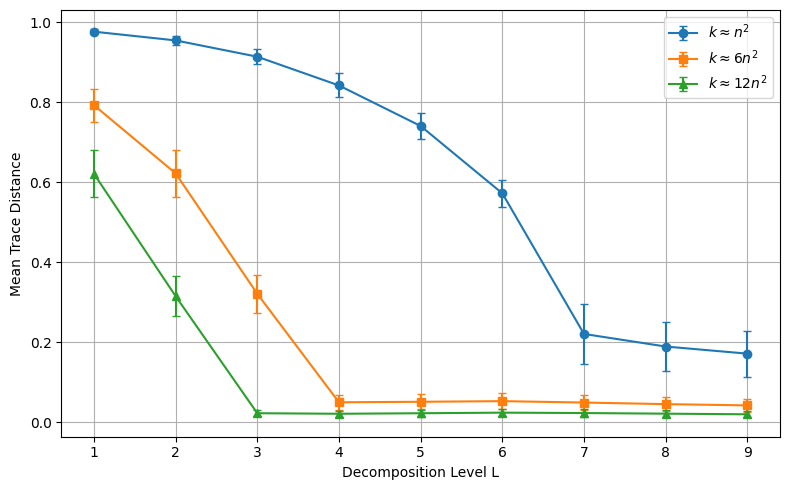

In [48]:
plt.figure(figsize=(8,5))

plt.errorbar(
    levels,
    mean_td[10],
    yerr=std_td[10],
    marker="o",
    capsize=3,
    label=r"$k \approx n^2$"
)

plt.errorbar(
    levels,
    mean_td[100],
    yerr=std_td[100],
    marker="s",
    capsize=3,
    label=r"$k \approx 6n^2$"
)

plt.errorbar(
    levels,
    mean_td[200],
    yerr=std_td[200],
    marker="^",
    capsize=3,
    label=r"$k\approx 12n^2$"
)

plt.xlabel(
    "Decomposition Level L"
)

plt.ylabel(
    "Mean Trace Distance"
)

plt.xticks(levels)

plt.grid(True)

plt.legend()

plt.tight_layout()
plt.savefig("../figures/PPG_dataset_analysis.pdf")
plt.show()